In [24]:
from skimage.feature import hog
from skimage.exposure import rescale_intensity

import cv2
import matplotlib.pyplot as plt
import numpy as np

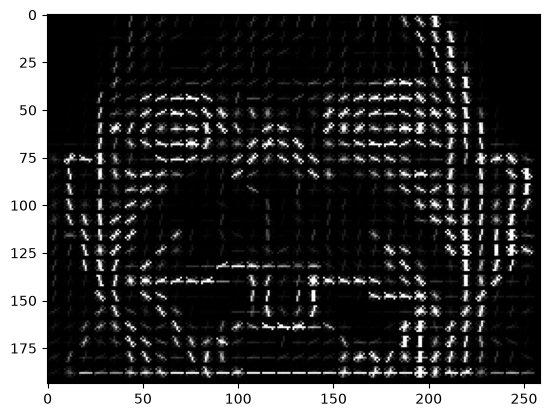

array([0.        , 0.        , 0.        , ..., 0.06776494, 0.        ,
       0.04756136], shape=(25668,))

In [ ]:
# Histogram of Gradients

# hog is normally good for static objects detection
# calculates localized gradients for each cell where each cell is usually 8x8 pixels
# divides them in angle bins usually 20-40 degree bins
# normalizes cells usually 2x2
# the normalized vectors of all these overlapping blocks are concatenated as the final feature vector

img = cv2.imread("Sukuna.jpg", cv2.IMREAD_GRAYSCALE)

features, hog_image = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)

hog_image_rescaled = rescale_intensity(hog_image, in_range=(0, 10))

plt.imshow(hog_image_rescaled, cmap="gray")
plt.show()

features

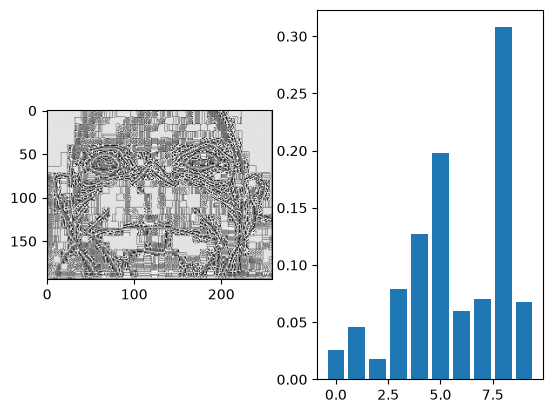

[0.02567369 0.04597381 0.0182104  0.07893166 0.12707479 0.19774708
 0.06008438 0.0707121  0.30774589 0.0678462 ]


In [38]:
from skimage.feature import local_binary_pattern

# Local Binary Pattern

# is normally good for texture feature extraction and facial recognition
# compares intensity of pixels with neighboring pixels
# creates binary patterns for within this neighborhood of pixels
# patterns form a histogram
# that serve as feature vectors

img = cv2.imread("Sukuna.jpg", cv2.IMREAD_GRAYSCALE)

radius = 1
n_points = 8 * radius

img_lpb = local_binary_pattern(img, n_points, radius, 'uniform')

hist, _ = np.histogram(img_lpb.ravel(), bins=np.arange(n_points + 3), range=range(n_points + 2))
hist = hist.astype(float)

hist /= hist.sum() + 1e-6

plt.subplot(1, 2, 1)
plt.imshow(img_lpb, cmap="gray")

plt.subplot(1, 2, 2)
plt.bar(range(n_points + 2), hist)
plt.show()

print(hist)

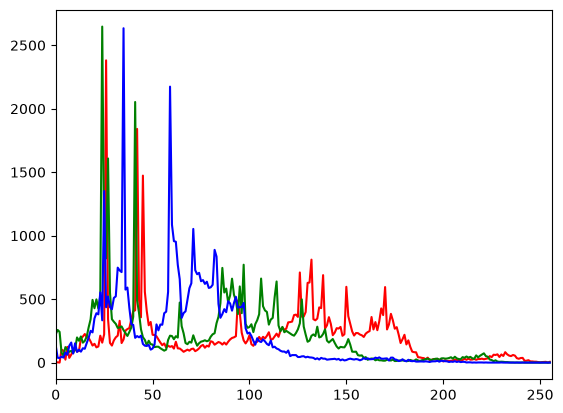

In [60]:
# Histogram of Colors

img = cv2.imread("Sukuna.jpg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hist_2d = cv2.calcHist([img], [0, 1, 2], None, [255, 255, 255], [0, 255, 0, 255, 0, 255])

for i, col in enumerate(['r', 'g', 'b']):
    # [images], [channel_index], mask, [histSize], [ranges]
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.xlim([0, 256])

plt.show()

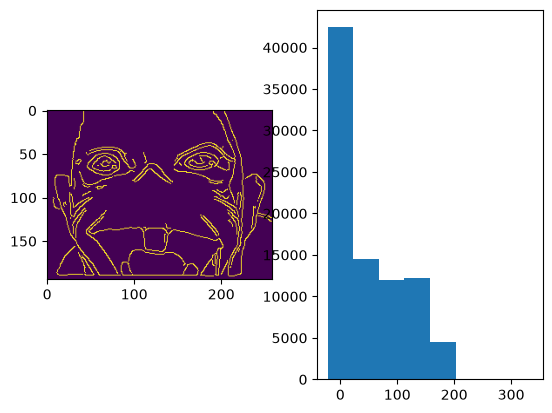

In [ ]:
# Histogram of Edge Directions / Histogram of Intensity Gradients

# captures distribution of edge direction. usually used in texture analysis, image segmentation, etc
# image must be grayscale and you can also apply smoothing to remove noise when finding edges
# apply edge detection algorithm. usually canny
# for each pixel in the edge map, calculate its orientation
# put the orientations into a histogram again (same bin logic as HOG)
# final histogram is our feature vector

img = cv2.imread("Sukuna.jpg")

img_smoothed = cv2.GaussianBlur(img, (5, 5), 0)

edge_map = cv2.Canny(img_smoothed, threshold1=30, threshold2=70)

plt.subplot(1, 2, 1)
plt.imshow(edge_map)

plt.subplot(1, 2, 2)
grad_x = cv2.Sobel(img_smoothed, cv2.CV_32F, 1, 0, ksize=3)
grad_y = cv2.Sobel(img_smoothed, cv2.CV_32F, 0, 1, ksize=3)
grad_mag = np.sqrt(grad_x**2 + grad_y**2)
grad_ort = np.arctan2(grad_y, grad_x) * 180 / np.pi
hist, bin_edges = np.histogram(grad_ort, bins=8, range=(0, 360))
plt.bar(bin_edges[:-1], hist, width=45)

plt.show()

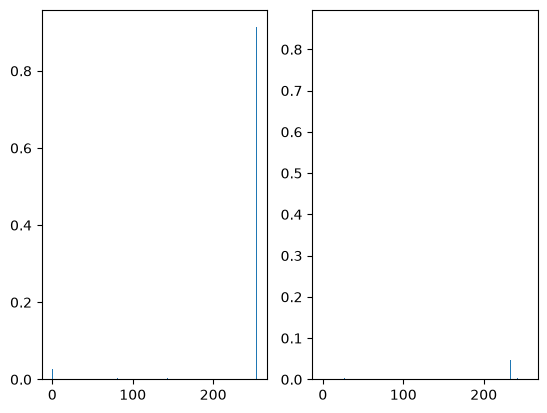

In [80]:
# Texture energy and contrast historgrams

# commonly used to analyze texture (no shit)
# texture energy measure smoothness of a texture
# it is the sum squared pixel intensities of the local neighborhood
# higher energy means complex texture and less uniformity

# texture contrast quantifies texture variation within local neihborhood
# std dev of pixel intensities in neighborhood
# higher contrast == hgiher variation

img = cv2.imread("Sukuna.jpg", cv2.IMREAD_GRAYSCALE)

nb_size = 3

ones = np.ones((nb_size, nb_size))
energy = cv2.filter2D(img**2, -1, ones)
contrast = cv2.filter2D(img, -1, ones)

energy_hist, energy_bins = np.histogram(energy, bins=256, range=(0, energy.max()))
contrast_hist, contrast_bins = np.histogram(contrast, bins=256, range=(0, contrast.max()))

energy_hist = energy_hist / energy_hist.sum()
contrast_hist = contrast_hist / contrast_hist.sum()

plt.subplot(1, 2, 1)
plt.bar(energy_bins[:-1], energy_hist)
plt.subplot(1, 2, 2)
plt.bar(contrast_bins[:-1], contrast_hist)

plt.show()

In [86]:
"""
we also have filters
you already know the basic ones
1) box: (kernel := np.ones((k, k)), kernel / kernel.sum())[1]
2) gaussian: cv2.getGaussianKernel(k, variance)
3) edge: dx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=k), dy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=k)
      dx = cv2.Scharr(img, cv2.CV_64F, 1, 0), dy = cv2.Scharr(img, cv2.CV_64F, 0, 1)
4) embossing (used to create a 3D effect near edges):
    np.array([
        [-2, -1, 0],
        [-1, 1, 1],
        [0, 1, 2],
        dtype=np.float32
    ])
"""

"""
Convolution Types:
1) Standard: centers kernel on every pixel. default of cv2.filter2D
2) Valid: set borderType=cv2.BORDER_CONSTANT in cv2.filter2D. This only convolves when the
    entire kernel is on the image
3) Same: borderType=cv2.BORDER_REFLECT adds zero padding outside the boundaries to create
    output with same dimensions as input
4) Strided: strides=(m, n)
"""

None

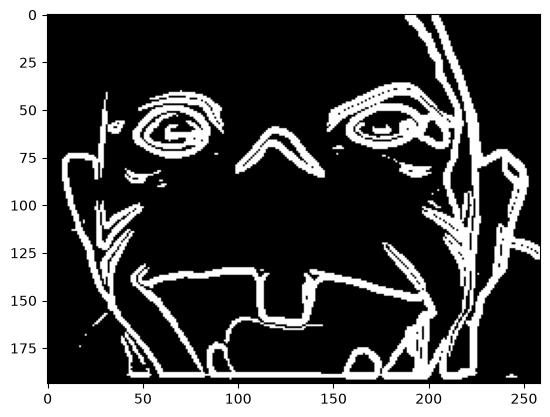

In [103]:
img_smoothed = cv2.filter2D(img, -1, np.ones((3, 3), dtype=np.float32) / 9)

dx = cv2.Sobel(img_smoothed, cv2.CV_64F, 1, 0, ksize=3)
dy = cv2.Sobel(img_smoothed, cv2.CV_64F, 0, 1, ksize=3)

grad_mag = np.sqrt(dy**2 + dx**2)
grad_ort = np.arctan2(dy, dx) * 180 / np.pi

threshold = 60
edge_map = (grad_mag > threshold).astype(np.uint8) * 255

plt.imshow(edge_map, cmap="gray")
plt.show()

In [ ]:
"""
How does Canny edge detector work?

1) apply gaussian smoothing
2) calculate sobel gradients and magnitude
3) supress smooth ends of edges by checking neighbors for every pixels. if current is higher then keep it.
   This allows it to thin edges and keep the most important bits
4) Some edges are noise, some edges are weak but still important. Use two thresholds
   Lines above T_high are kept instantly. Lines below T_low are discarded. Between ones are kept for analysis
   All the pixels of the weak edges are checked to see if they connect to a strong edge. If yes then it's considered
   valid weak edge rather than noise edge. Otherwise, discarded
"""